# Mini CNN Classifier for S3M NEO Probability

This notebook is a small neural-network testbed for comparing a CNN-style classifier against the existing VDP Bayesian velocity-density classifier and digest2.

It follows the same practical PyTorch style as `Lab4_Devanshi.ipynb`: prepare arrays, reshape into `(N, channels, height, width)`, define a `torch.nn.Module`, train with mini-batches, track loss/validation metrics, then evaluate on a held-out test set.

**Goal for this first pass:** train a compact CNN on the already-propagated corrected digest2/VDP comparison sample, then compare:

- `CNN P(NEO)` from supervised labels
- `VDP P_NEO` from the Bayesian density maps
- `digest2` NEO score

This is intentionally a mini test, not the final neural-net paper result.

## 1. Setup

The input file is the corrected comparison parquet from the parent `neomod/` folder. It has one row per visible S3M object and includes the observables needed for the mini CNN image representation.

In [1]:
%matplotlib inline

from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

RANDOM_SEED = 55
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DATA_PATH = Path("..") / "s3m_digest2_comparison.parquet"
IMAGE_SIZE = 32
VEL_LIM = (-0.8, 0.8)
MAG_RANGE = (14.0, 26.0)
EPOCHS = 20
BATCH_SIZE = 512
LEARNING_RATE = 1e-3

if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("device:", device)
print("data path:", DATA_PATH.resolve())

device: mps
data path: /Users/devanshisingh/Downloads/research/NEO_probability/neomod/s3m_digest2_comparison.parquet


## 2. Load the Corrected VDP/digest2 Comparison Sample

Labels are binary:

```text
1 = true S3M NEO
0 = MBA, TNO, or Trojan
```

The neural net does not use `P_NEO_vdp` or `P_NEO_d2` as input. Those columns are held back as benchmark scores.

In [2]:
df = pd.read_parquet(DATA_PATH)
required = ["true_population", "lam_deg", "vlam", "vbeta", "mag_app", "P_NEO_vdp", "P_NEO_d2"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Keep only finite rows inside the VDP velocity/magnitude domain.
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=required).reset_index(drop=True)
df = df[
    (df["vlam"].between(*VEL_LIM))
    & (df["vbeta"].between(*VEL_LIM))
    & (df["mag_app"].between(MAG_RANGE[0], MAG_RANGE[1], inclusive="left"))
].reset_index(drop=True)

df["is_neo"] = (df["true_population"] == "NEO").astype(np.int64)

print(f"Rows: {len(df):,}")
print(df["true_population"].value_counts().to_string())
print(f"NEO fraction: {df['is_neo'].mean():.2%}")
display(df.head())

Rows: 38,045
true_population
MBA        15350
Trojans    13035
TNO         7427
NEO         2233
NEO fraction: 5.87%


,true_population,lam_deg,vlam,vbeta,mag_app,H,P_NEO_vdp,P_NEO_d2,is_neo
0,NEO,188.213266,-0.224582,0.020553,18.110710,11.452,0.000172,0.41,1
1,NEO,169.925547,-0.346591,0.053089,16.340715,12.430,0.519185,0.96,1
2,NEO,190.416689,-0.385974,-0.013405,17.992193,13.901,0.847608,1.00,1
3,NEO,163.777123,-0.258691,0.032913,18.760917,14.092,0.000304,0.60,1
4,NEO,175.908696,-0.274626,-0.008760,20.302876,15.092,0.004728,0.15,1


## 3. Velocity-Space CNN Images

Each object becomes a tiny 3-channel velocity-space image:

- channel 0: a Gaussian dot at `(v_lambda, v_beta)`
- channel 1: the same dot weighted by normalized apparent magnitude
- channel 2: the same dot weighted by normalized ecliptic longitude within this patch

This keeps the first CNN test close to the VDP observables while still using an image-like input. The network is learning from labels, not from the VDP probability map.

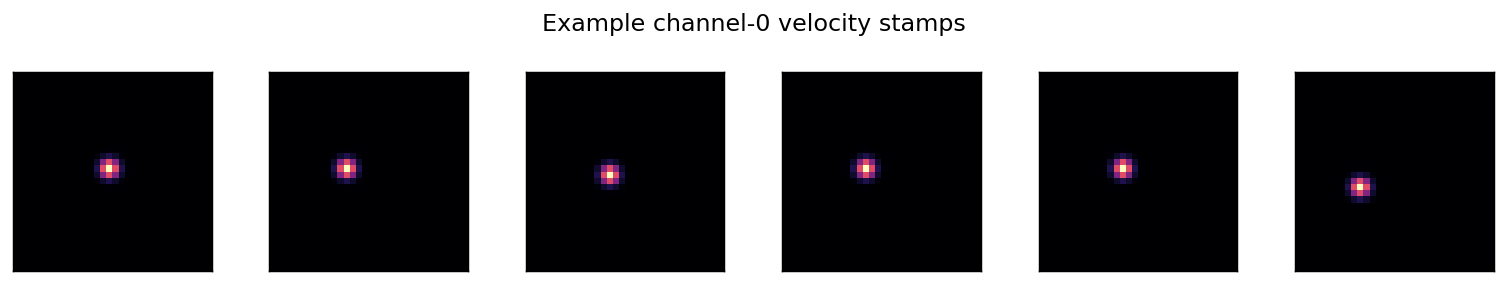

In [3]:
def normalize_mag(mag_app, mag_range=MAG_RANGE):
    lo, hi = mag_range
    return np.clip((np.asarray(mag_app, dtype=float) - lo) / (hi - lo), 0.0, 1.0)


def normalize_lam_patch(lam_deg):
    # The corrected comparison patch is centered near opposition at lambda ~= 180 deg.
    # Wrap to [-180, 180], then scale a +/-30 deg region to approximately [0, 1].
    delta = ((np.asarray(lam_deg, dtype=float) - 180.0 + 180.0) % 360.0) - 180.0
    return np.clip((delta + 30.0) / 60.0, 0.0, 1.0)


def make_velocity_images(frame, image_size=IMAGE_SIZE, vel_lim=VEL_LIM, sigma_px=1.0, radius_px=3):
    """Rasterize object observables into small CNN images.

    Output shape follows PyTorch CNN convention: (N, channels, height, width).
    """
    n = len(frame)
    images = np.zeros((n, 3, image_size, image_size), dtype=np.float32)

    vlam = frame["vlam"].to_numpy(float)
    vbeta = frame["vbeta"].to_numpy(float)
    mag = normalize_mag(frame["mag_app"].to_numpy(float))
    lam = normalize_lam_patch(frame["lam_deg"].to_numpy(float))

    lo, hi = vel_lim
    x = (vlam - lo) / (hi - lo) * (image_size - 1)
    y = (vbeta - lo) / (hi - lo) * (image_size - 1)

    offsets = np.arange(-radius_px, radius_px + 1)
    yy, xx = np.meshgrid(offsets, offsets, indexing="ij")
    kernel = np.exp(-(xx**2 + yy**2) / (2.0 * sigma_px**2)).astype(np.float32)
    kernel /= kernel.max()

    for i in range(n):
        cx = int(np.rint(x[i]))
        cy = int(np.rint(y[i]))
        if cx < 0 or cx >= image_size or cy < 0 or cy >= image_size:
            continue

        # Put low v_beta at bottom for visual sanity when plotted with origin='lower'.
        row_center = cy
        col_center = cx

        for ky, dy in enumerate(offsets):
            row = row_center + dy
            if row < 0 or row >= image_size:
                continue
            for kx, dx in enumerate(offsets):
                col = col_center + dx
                if col < 0 or col >= image_size:
                    continue
                val = kernel[ky, kx]
                images[i, 0, row, col] = max(images[i, 0, row, col], val)
                images[i, 1, row, col] = max(images[i, 1, row, col], val * mag[i])
                images[i, 2, row, col] = max(images[i, 2, row, col], val * lam[i])

    return images


sample_imgs = make_velocity_images(df.sample(6, random_state=RANDOM_SEED))
fig, axes = plt.subplots(1, 6, figsize=(12, 2.2))
for ax, img in zip(axes, sample_imgs):
    ax.imshow(img[0], origin="lower", cmap="magma", vmin=0, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("Example channel-0 velocity stamps")
plt.tight_layout()
plt.show()

## 4. Train / Validation / Test Split

The split is stratified so the NEO fraction is similar in each subset.

In [4]:
idx = np.arange(len(df))
y = df["is_neo"].to_numpy(np.int64)

idx_train, idx_temp, y_train, y_temp = train_test_split(
    idx, y, test_size=0.30, random_state=RANDOM_SEED, stratify=y
)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp
)

splits = {
    "train": idx_train,
    "validation": idx_val,
    "test": idx_test,
}
for name, ind in splits.items():
    print(f"{name:10s}: n={len(ind):6,d}, NEO fraction={df.iloc[ind]['is_neo'].mean():.2%}")

train     : n=26,631, NEO fraction=5.87%
validation: n= 5,707, NEO fraction=5.87%
test      : n= 5,707, NEO fraction=5.87%


In [5]:
print("Rasterizing images...")
X_train = make_velocity_images(df.iloc[idx_train])
X_val = make_velocity_images(df.iloc[idx_val])
X_test = make_velocity_images(df.iloc[idx_test])

train_inputs = torch.from_numpy(X_train).float()
validation_inputs = torch.from_numpy(X_val).float()
testing_inputs = torch.from_numpy(X_test).float()

train_targets = torch.from_numpy(y_train).long()
validation_targets = torch.from_numpy(y_val).long()
testing_targets = torch.from_numpy(y_test).long()

train_loader = DataLoader(
    TensorDataset(train_inputs, train_targets),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

print("train tensor:", tuple(train_inputs.shape))
print("validation tensor:", tuple(validation_inputs.shape))
print("test tensor:", tuple(testing_inputs.shape))

Rasterizing images...


train tensor: (26631, 3, 32, 32)
validation tensor: (5707, 3, 32, 32)
test tensor: (5707, 3, 32, 32)


## 5. Define the CNN

This mirrors the Lab 4 pattern: convolution, ReLU, max-pooling, another convolution, then fully connected layers. The output has two logits: non-NEO and NEO.

In [6]:
class VelocityCNN(torch.nn.Module):
    def __init__(self, in_channels=3, image_size=IMAGE_SIZE):
        super(VelocityCNN, self).__init__()

        self.cnn1 = torch.nn.Conv2d(in_channels=in_channels, out_channels=16, kernel_size=5, stride=1, padding=2)
        self.maxpool1 = torch.nn.MaxPool2d(kernel_size=2)
        self.cnn2 = torch.nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=2)
        self.maxpool2 = torch.nn.MaxPool2d(kernel_size=2)
        self.cnn3 = torch.nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)

        pooled = image_size // 4
        self.fc1 = torch.nn.Linear(64 * pooled * pooled, 128)
        self.fc2 = torch.nn.Linear(128, 2)
        self.dropout = torch.nn.Dropout(p=0.15)

    def forward(self, x):
        x = torch.nn.functional.relu(self.cnn1(x))
        x = self.maxpool1(x)
        x = torch.nn.functional.relu(self.cnn2(x))
        x = self.maxpool2(x)
        x = torch.nn.functional.relu(self.cnn3(x))
        x = x.view(x.size(0), -1)
        x = torch.nn.functional.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


model = VelocityCNN().to(device)

counts = np.bincount(y_train, minlength=2)
class_weights = torch.tensor(len(y_train) / (2.0 * counts), dtype=torch.float32).to(device)
loss_func = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)
print("class counts:", counts)
print("class weights:", class_weights.detach().cpu().numpy())

VelocityCNN(
  (cnn1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (cnn2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (cnn3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
  (dropout): Dropout(p=0.15, inplace=False)
)
class counts: [25068  1563]
class weights: [0.5311752 8.519194 ]


## 6. Metrics

To compare fairly with VDP and digest2, use the same NEO-selection metrics:

```text
completeness = true NEOs selected / all true NEOs
contamination = non-NEOs selected / all selected candidates
purity = 1 - contamination
F1 = harmonic mean of completeness and purity
```

In [7]:
def score_model(model, inputs, batch_size=4096):
    model.eval()
    probs = []
    with torch.no_grad():
        for start in range(0, len(inputs), batch_size):
            xb = inputs[start:start + batch_size].to(device)
            logits = model(xb)
            p_neo = torch.softmax(logits, dim=1)[:, 1]
            probs.append(p_neo.detach().cpu())
    return torch.cat(probs).numpy()


def metric_at_threshold(scores, y_true, threshold):
    selected = scores >= threshold
    neo = y_true.astype(bool)
    tp = np.sum(selected & neo)
    fp = np.sum(selected & ~neo)
    n_neo = np.sum(neo)
    completeness = tp / max(n_neo, 1)
    contamination = fp / max(tp + fp, 1)
    purity = 1.0 - contamination
    f1 = 0.0 if purity + completeness == 0 else 2 * purity * completeness / (purity + completeness)
    return completeness, contamination, purity, f1, tp, fp, selected.sum()


def curve_and_best(scores, y_true, thresholds=np.linspace(0, 1, 401)):
    rows = []
    for t in thresholds:
        comp, cont, pur, f1, tp, fp, nsel = metric_at_threshold(scores, y_true, t)
        rows.append((t, comp, cont, pur, f1, tp, fp, nsel))
    out = pd.DataFrame(rows, columns=["threshold", "completeness", "contamination", "purity", "F1", "TP", "FP", "selected"])
    best = out.iloc[out["F1"].idxmax()]
    return out, best

## 7. Train Model

The validation readout reports both accuracy and best-F1 threshold behavior, because accuracy alone is misleading for an imbalanced NEO/non-NEO sample.

In [8]:
train_loss_list = []
validation_accuracy_list = np.zeros(EPOCHS)
validation_f1_list = np.zeros(EPOCHS)

for epoch in range(EPOCHS):
    model.train()
    running_losses = []

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = loss_func(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss_list.append(loss.item())
        running_losses.append(loss.item())

    with torch.no_grad():
        validation_probs = score_model(model, validation_inputs)
        validation_pred = validation_probs >= 0.5
        validation_accuracy = np.mean(validation_pred == y_val)
        _, validation_best = curve_and_best(validation_probs, y_val)

    validation_accuracy_list[epoch] = validation_accuracy
    validation_f1_list[epoch] = validation_best["F1"]

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"train loss={np.mean(running_losses):.4f} | "
        f"val acc@0.5={validation_accuracy:.3f} | "
        f"val best F1={validation_best['F1']:.3f} "
        f"(t={validation_best['threshold']:.3f}, comp={validation_best['completeness']:.1%}, cont={validation_best['contamination']:.1%})"
    )

Epoch 01/20 | train loss=0.3878 | val acc@0.5=0.952 | val best F1=0.797 (t=0.835, comp=75.2%, cont=15.2%)


Epoch 02/20 | train loss=0.2380 | val acc@0.5=0.970 | val best F1=0.795 (t=0.740, comp=71.3%, cont=10.2%)


Epoch 03/20 | train loss=0.2326 | val acc@0.5=0.958 | val best F1=0.807 (t=0.713, comp=76.1%, cont=14.1%)


Epoch 04/20 | train loss=0.2203 | val acc@0.5=0.959 | val best F1=0.816 (t=0.613, comp=78.2%, cont=14.7%)


Epoch 05/20 | train loss=0.2154 | val acc@0.5=0.951 | val best F1=0.819 (t=0.860, comp=77.0%, cont=12.5%)


...

Epoch 16/20 | train loss=0.1743 | val acc@0.5=0.949 | val best F1=0.848 (t=0.945, comp=76.7%, cont=5.2%)


Epoch 17/20 | train loss=0.1679 | val acc@0.5=0.958 | val best F1=0.865 (t=0.930, comp=78.2%, cont=3.3%)


Epoch 18/20 | train loss=0.1817 | val acc@0.5=0.977 | val best F1=0.852 (t=0.860, comp=76.4%, cont=3.8%)


Epoch 19/20 | train loss=0.2029 | val acc@0.5=0.947 | val best F1=0.846 (t=0.823, comp=82.1%, cont=12.7%)


Epoch 20/20 | train loss=0.1705 | val acc@0.5=0.960 | val best F1=0.847 (t=0.878, comp=78.5%, cont=8.0%)


## 8. Training Curves

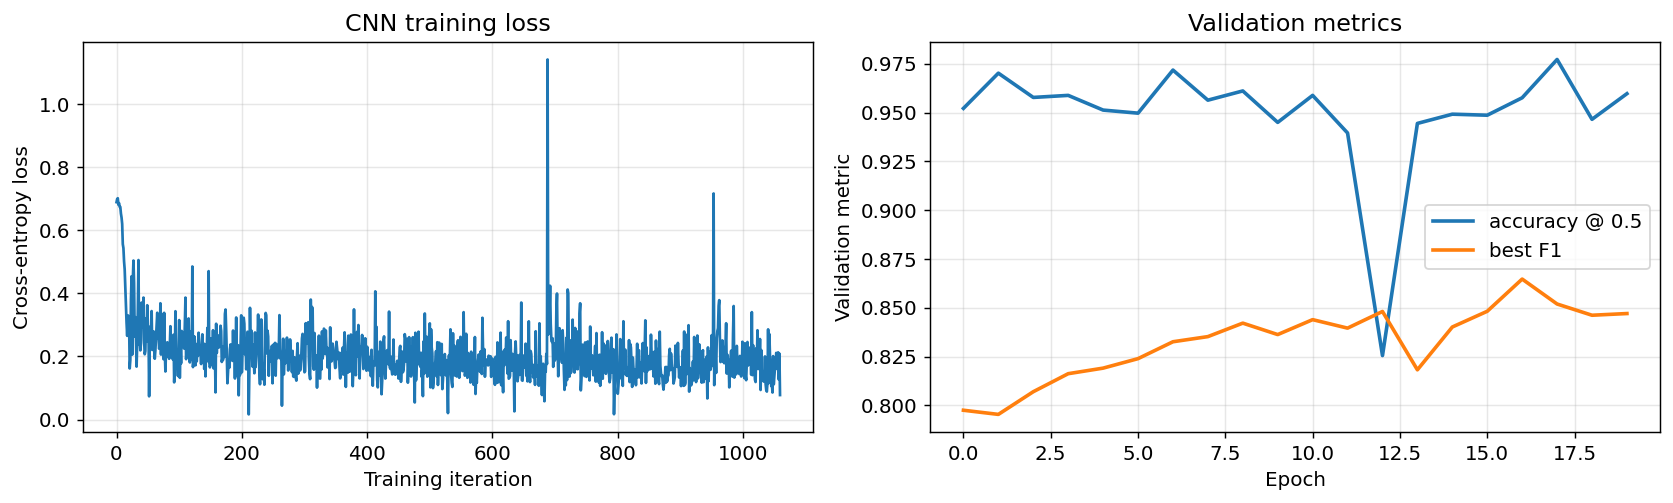

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(train_loss_list, lw=1.5)
axes[0].set_xlabel("Training iteration")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].set_title("CNN training loss")
axes[0].grid(alpha=0.3)

axes[1].plot(validation_accuracy_list, lw=2, label="accuracy @ 0.5")
axes[1].plot(validation_f1_list, lw=2, label="best F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation metric")
axes[1].set_title("Validation metrics")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Held-Out Test Comparison: CNN vs VDP vs digest2

Now compare all three classifiers on exactly the same held-out test rows.

In [10]:
test_df = df.iloc[idx_test].copy().reset_index(drop=True)
y_test_np = test_df["is_neo"].to_numpy(np.int64)

scores = {
    "CNN": score_model(model, testing_inputs),
    "VDP": test_df["P_NEO_vdp"].to_numpy(float),
    "digest2": test_df["P_NEO_d2"].to_numpy(float),
}

summary_rows = []
curves = {}
for name, score in scores.items():
    curve, best = curve_and_best(score, y_test_np)
    curves[name] = curve
    try:
        auc = roc_auc_score(y_test_np, score)
    except ValueError:
        auc = np.nan
    summary_rows.append({
        "classifier": name,
        "AUC": auc,
        "best_threshold": best["threshold"],
        "completeness": best["completeness"],
        "contamination": best["contamination"],
        "purity": best["purity"],
        "F1": best["F1"],
        "selected": int(best["selected"]),
        "TP": int(best["TP"]),
        "FP": int(best["FP"]),
    })

summary = pd.DataFrame(summary_rows).sort_values("F1", ascending=False)
display(summary.style.format({
    "AUC": "{:.3f}",
    "best_threshold": "{:.3f}",
    "completeness": "{:.1%}",
    "contamination": "{:.1%}",
    "purity": "{:.1%}",
    "F1": "{:.3f}",
}))

,classifier,AUC,best_threshold,completeness,contamination,purity,F1,selected,TP,FP
0,CNN,0.983,0.910,81.2%,5.2%,94.8%,0.875,287,272,15
1,VDP,0.979,0.005,80.9%,5.6%,94.4%,0.871,287,271,16
2,digest2,0.863,0.950,53.4%,11.8%,88.2%,0.665,203,179,24


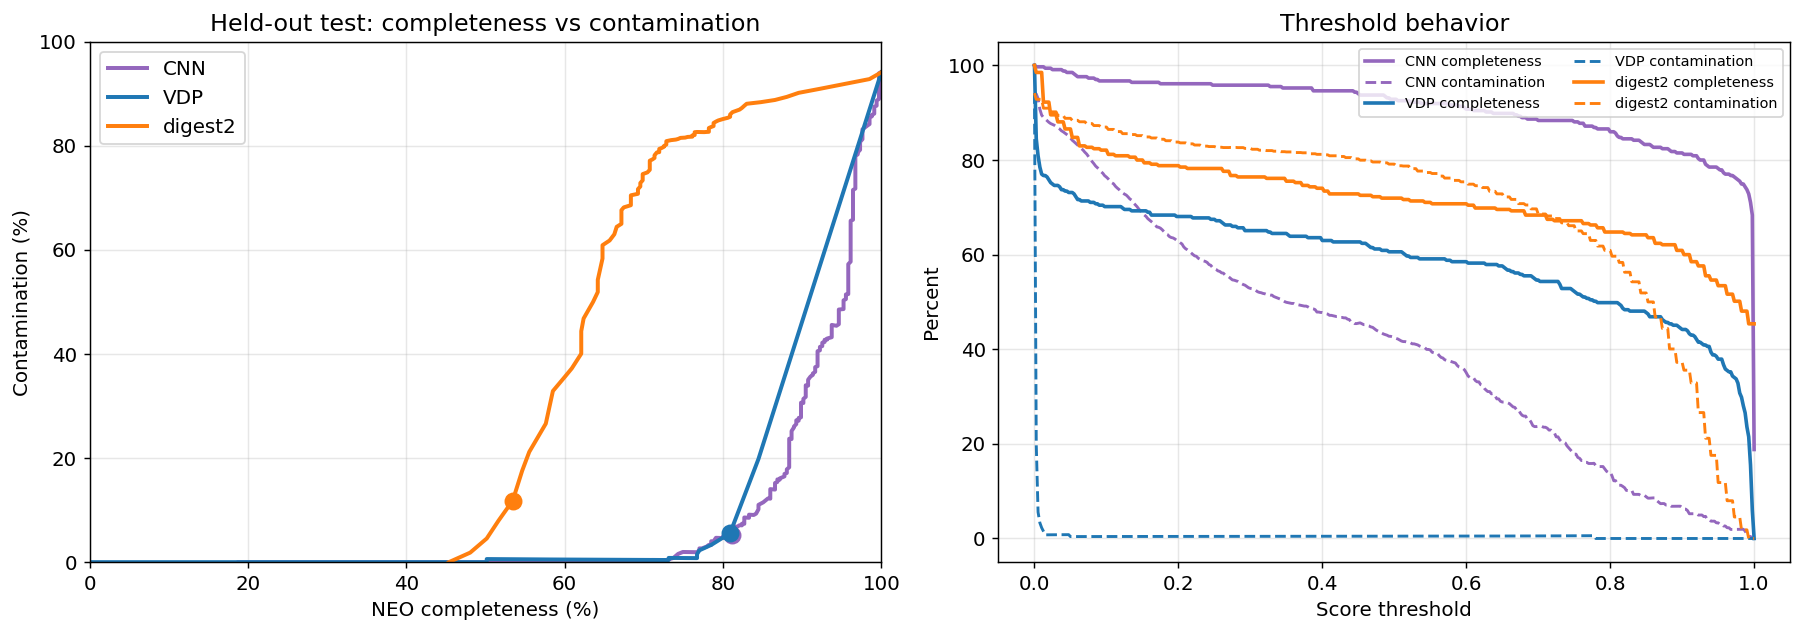

In [11]:
colors = {"CNN": "tab:purple", "VDP": "tab:blue", "digest2": "tab:orange"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name, curve in curves.items():
    ax.plot(curve["completeness"] * 100, curve["contamination"] * 100, lw=2.2, label=name, color=colors[name])
    best = curve.iloc[curve["F1"].idxmax()]
    ax.scatter(best["completeness"] * 100, best["contamination"] * 100, s=80, color=colors[name], zorder=5)
ax.set_xlabel("NEO completeness (%)")
ax.set_ylabel("Contamination (%)")
ax.set_title("Held-out test: completeness vs contamination")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)
ax.legend()

ax = axes[1]
for name, curve in curves.items():
    ax.plot(curve["threshold"], curve["completeness"] * 100, lw=2, color=colors[name], label=f"{name} completeness")
    ax.plot(curve["threshold"], curve["contamination"] * 100, lw=1.6, color=colors[name], linestyle="--", label=f"{name} contamination")
ax.set_xlabel("Score threshold")
ax.set_ylabel("Percent")
ax.set_title("Threshold behavior")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

## 10. Score Distributions

These histograms show whether the CNN separates true NEOs from the three non-NEO populations in the same qualitative way as VDP/digest2.

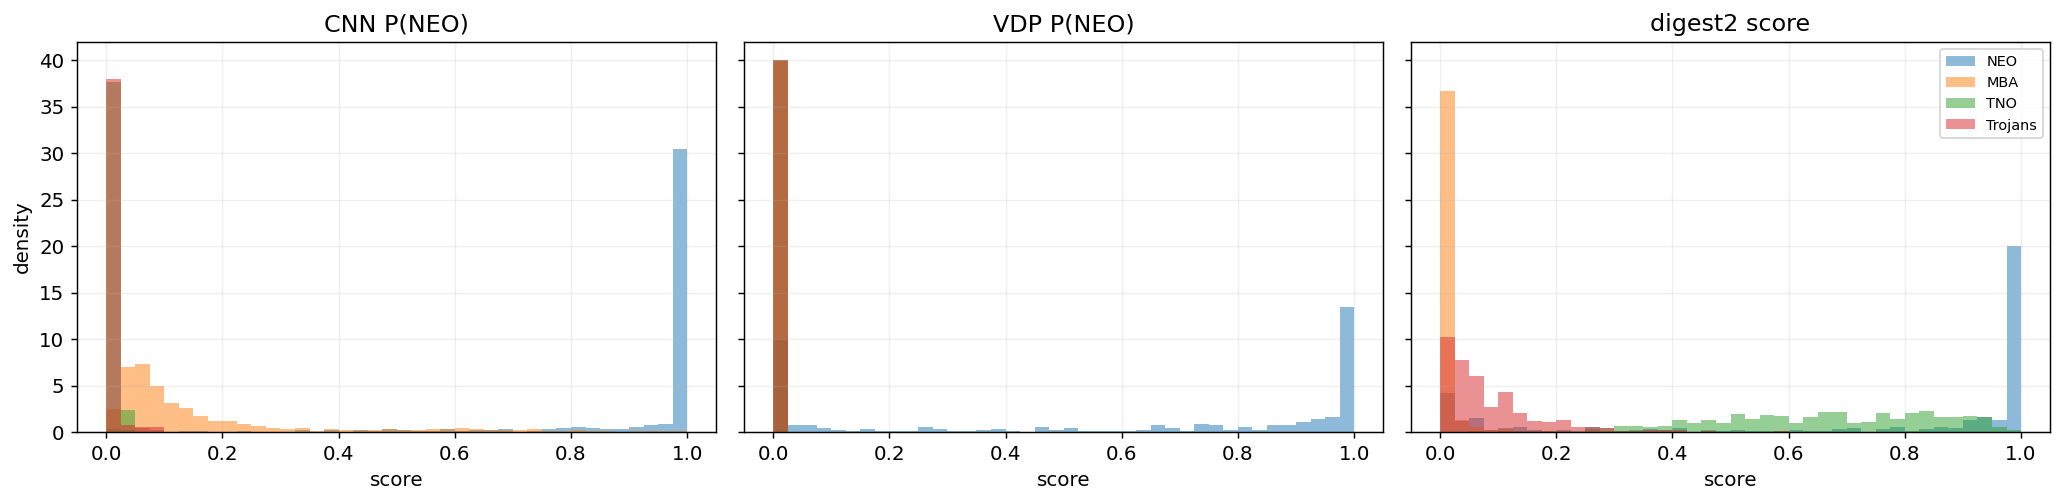

In [12]:
test_df["P_NEO_cnn"] = scores["CNN"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
score_cols = [
    ("P_NEO_cnn", "CNN P(NEO)"),
    ("P_NEO_vdp", "VDP P(NEO)"),
    ("P_NEO_d2", "digest2 score"),
]
pop_colors = {"NEO": "tab:blue", "MBA": "tab:orange", "TNO": "tab:green", "Trojans": "tab:red"}

for ax, (col, title) in zip(axes, score_cols):
    for pop in ["NEO", "MBA", "TNO", "Trojans"]:
        sub = test_df.loc[test_df["true_population"] == pop, col]
        ax.hist(sub, bins=40, range=(0, 1), density=True, alpha=0.50, label=pop, color=pop_colors[pop])
    ax.set_title(title)
    ax.set_xlabel("score")
    ax.grid(alpha=0.2)
axes[0].set_ylabel("density")
axes[-1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 11. Top-N Follow-Up Yield

This is often closer to the observing question: if we follow up only the top-ranked objects, how many true NEOs do we get?

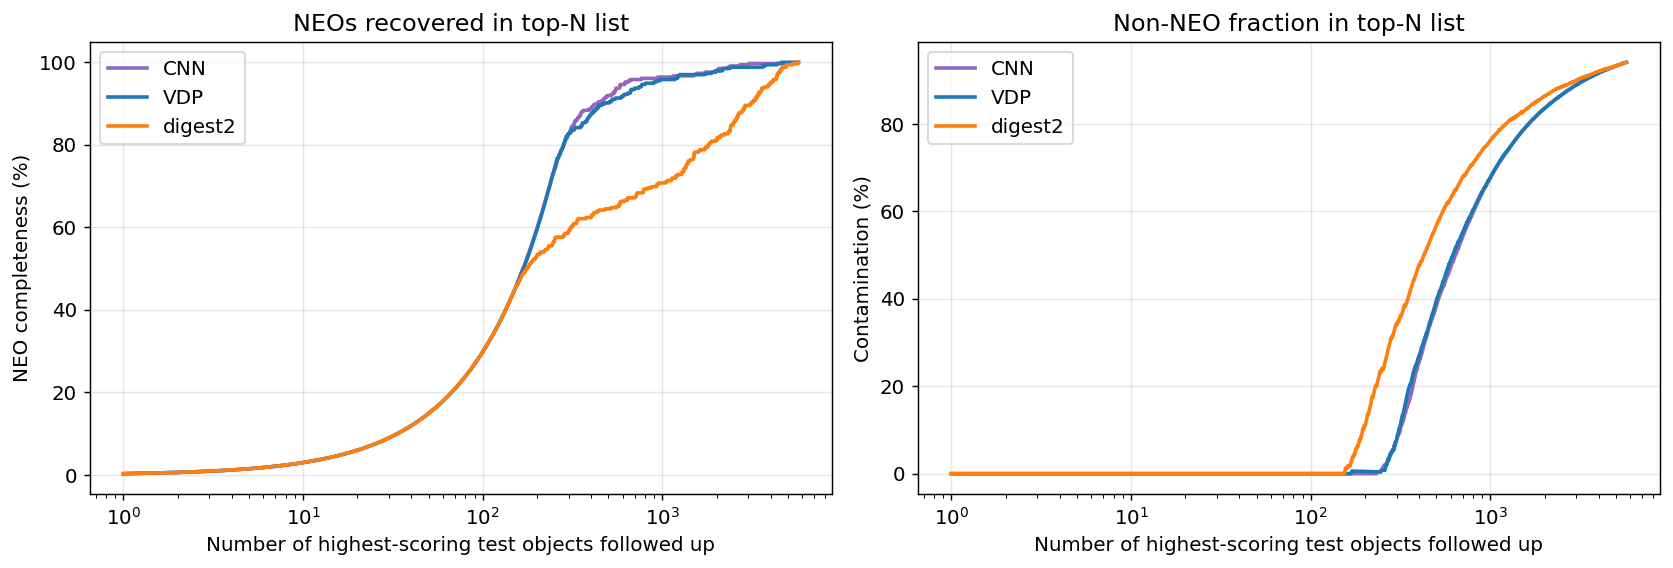

neo_recovered                completeness_pct                 \
classifier           CNN    VDP digest2              CNN    VDP digest2   
n_followed                                                                
25                  25.0   25.0    25.0             7.46   7.46    7.46   
50                  50.0   50.0    50.0            14.93  14.93   14.93   
100                100.0  100.0   100.0            29.85  29.85   29.85   
250                248.0  248.0   190.0            74.03  74.03   56.72   
500                308.0  302.0   216.0            91.94  90.15   64.48   
1000               323.0  321.0   237.0            96.42  95.82   70.75   
2500               332.0  331.0   287.0            99.10  98.81   85.67   

           contamination_pct                 
classifier               CNN    VDP digest2  
n_followed                                   
25                      0.00   0.00    0.00  
50                      0.00   0.00    0.00  
100                     0.00   0.00    0.00  
250                     0.80   0.80   24.00  
500                    38.40  39.60   56.80  
1000                   67.70  67.90   76.30  
2500                   86.72  86.76   88.52

In [13]:
def followup_curve(frame, score_col, label):
    ordered = frame.sort_values(score_col, ascending=False).reset_index(drop=True)
    selected = np.arange(1, len(ordered) + 1)
    neo_cum = (ordered["true_population"] == "NEO").cumsum().to_numpy()
    n_neo = (frame["true_population"] == "NEO").sum()
    return pd.DataFrame({
        "n_followed": selected,
        "neo_recovered": neo_cum,
        "completeness": neo_cum / max(n_neo, 1),
        "contamination": 1.0 - neo_cum / selected,
        "classifier": label,
    })

followup = pd.concat([
    followup_curve(test_df, "P_NEO_cnn", "CNN"),
    followup_curve(test_df, "P_NEO_vdp", "VDP"),
    followup_curve(test_df, "P_NEO_d2", "digest2"),
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
for label in ["CNN", "VDP", "digest2"]:
    sub = followup[followup["classifier"] == label]
    axes[0].plot(sub["n_followed"], sub["completeness"] * 100, lw=2, label=label, color=colors[label])
    axes[1].plot(sub["n_followed"], sub["contamination"] * 100, lw=2, label=label, color=colors[label])

for ax in axes:
    ax.set_xscale("log")
    ax.set_xlabel("Number of highest-scoring test objects followed up")
    ax.grid(alpha=0.3)
    ax.legend()
axes[0].set_ylabel("NEO completeness (%)")
axes[0].set_title("NEOs recovered in top-N list")
axes[1].set_ylabel("Contamination (%)")
axes[1].set_title("Non-NEO fraction in top-N list")
plt.tight_layout()
plt.show()

summary_n = [25, 50, 100, 250, 500, 1000, 2500]
summary_n = [n for n in summary_n if n <= len(test_df)]
followup_summary = (
    followup[followup["n_followed"].isin(summary_n)]
    .assign(completeness_pct=lambda x: x["completeness"] * 100,
            contamination_pct=lambda x: x["contamination"] * 100)
    .pivot(index="n_followed", columns="classifier", values=["neo_recovered", "completeness_pct", "contamination_pct"])
)
display(followup_summary.round(2))

## 12. Notes for the Next, Less-Mini Version

This notebook answers: *can a small supervised CNN learn a useful NEO/non-NEO boundary from the same synthetic visible-object sample?*

Important caveats:

- The CNN is trained and tested on S3M rows from one corrected comparison dataset, so this is not yet a cross-epoch or cross-field generalization test.
- The velocity image is deliberately simple. It is closer to a learned velocity/magnitude decision surface than to a full survey-image CNN.
- For a stronger neural comparison, train on one epoch/sky patch and test on another, or generate multiple VDP-like fields and hold out entire fields.
- Do not include `P_NEO_vdp` as an input feature unless the goal is explicitly to emulate VDP.